# Machine Learning Project

### Giacomo Cordella

## Introduction to the Project

The project main scope is to predict the market value of football players (soccer players), given some data about their statistics and informations.

To achieve this goal, we will go through some data analysis, meaning feature selection, data preprocessing, data normalization, model selction, model training and evaluation and finally model prediction

Initially, we must import all the libraries we are going to use throughout the project, many of which come from **Scikit Learn** and **PyTorch**

In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

import seaborn as sns
from tqdm import tqdm

## The Work Flow

For the project, I have used a work flow which sees first the definition of several functions that I will use later in the code. These functions are going to do the data processing and feature selection for my databases.


Now that all the libraries are set, we can proceed to the first task, which is uploading the datasets.

We are going to use the "_os_" library to access the files in the computer and take the one we need, and in addition we are going to fix the seed for replicability.

**NOTE**: to use this directories you must have this file in a folder, with a folder inside named "_data_", in which are contained the CSV Files with the datasets

In [40]:

# Define the path of the data and images
current_dir = os.getcwd()  # Get the current working directory
DATA_DIR = "./data"
IMG_DIR = "./img"
F_CSV_TRAIN = os.path.join(DATA_DIR, "train.csv")
F_CSV_TEST = os.path.join(DATA_DIR, "test.csv")
F_CSV_SUB = os.path.join(DATA_DIR, "submission.csv")

# Fixing the seed for replicability
SEED = 1

## Functions Definition

### Dataset Loading and Data Pre-processing

The first function we introduce is used to **Load the Data**: it is going to read a CSV File and transform it in a Pandas Database

In [41]:
def load_data(file_path, verbose=True):
    """
    This function is used to load the data from a csv file
    @param file_path: the path of the csv file
    @return: the dataset loaded
    """
    dataset = pd.read_csv(file_path) # Load the dataset

    if verbose:
        print(f"DATASET LOADED - Number of features: {dataset.shape[1]}")
        print(f"DATASET LOADED - Number of samples: {dataset.shape[0]}")

    return dataset

The next function we are going to define will be used to **Pre-select the features**, i.e. we are going to eliminate all those variables that are not informative for our predictions and estimations.

infact, regressor like "short name", "long name", "player id" and so on are not that usefull when trying to predict their market value, therefore the following function will take care of that and remove all the useless features.

In [42]:
def features_pre_selection (dataset):
    """
    This function is used to eliminate the features that are useless
    @param dataset: the dataset to be preprocessed
    @return: the dataset without the useless features
    """

    # Select the feature that are useless (without any useful information)
    features_useless = ['Unnamed: 0','id','short_name','long_name','dob','club_name',
                'league_name', 'club_jersey_number', 'club_joined','nationality_name',
                'nation_jersey_number', 'club_team_id', 'nationality_id','preferred_foot', 
                'work_rate', 'body_type', 'player_tags', 'player_traits']
    
    # Eliminating the features that are useless
    df_pre_selected = dataset.drop(features_useless, axis=1)

    return df_pre_selected

In the dataset, however, there are some variables which are categorical (non-numerical) but not completely useless because they might carry informations about the players that can be directly or indirectly linked to their market value, and with some data engineering we could use them in our predictions.

The variables with the respective processing idea are the following:
* **Player Position**: this variable tells us the position a player can play, to use this variable we could split every position for each player and make them dummy variables containing the release clause mean for that specific position, we do this to carry some more information than just the position played.

* **Nation Position**: this variable tells us the position a player plays in its national team. The real information behind this variable is if a player is good enough to play in its national team and therefore we could transform the entries of the column in a boolean values.

* **Club Loaned From**: this variable tells us the club from which the player is coming. As the prior variable we are more intrested in if the player is loned or not.

* **Club Position**: this variable tells us the position a player plays in his club. The importance of these variable is in the information of the player playing as Starter, as Substitute or if he is a Reserve.

* **Contract Valid Untill**: this variable tells us what year is the contract with the club expiring. This information is usefull to understand how far is the player for the end of his contract because usually players closer to the end of the contracts tend to have lower market values then when just signed.

With the following function therefore we are going to handle of of these variables and embed them into our initial dataset:

In [43]:
def features_embedding(dataset):
    """
    This function is used to preprocess the dataset for the features embedding
    @param dataset: the dataset to be processed
    @return: the dataset with the processed features
    """

    # "Target Encoding": transform 'player_positions' into embedded features
    # Every category is replaced by the mean of release_clause_eur for that category.
    if 'player_positions' in dataset.columns:
        mean_target = dataset.groupby('player_positions')['release_clause_eur'].mean()
        dataset['player_positions'] = dataset['player_positions'].map(mean_target)
        dataset = dataset.drop(['player_positions'], axis=1)

    # Selecting if player plays in the national team
    dataset['nation_position'] = dataset['nation_position'].apply(lambda x: 0 if pd.isna(x) else 1)

    # Selecting if the player is loaned
    dataset['club_loaned_from'] = dataset['club_loaned_from'].apply(lambda x: 0 if pd.isna(x) else 1)

    # Selecting the playing players
    dataset['club_position'] = dataset['club_position'].apply(lambda x: 'PLAY' if x != 'SUB' and x != 'RES' else x)
    dummy_play  = pd.get_dummies(dataset['club_position'])
    dataset = pd.concat([dataset, dummy_play], axis=1)
    dataset = dataset.drop(['club_position'], axis=1)

    # Selecting data end contract
    if dataset['club_contract_valid_until'].notnull().any():
        # Sobistituting the NaN values with the minimum value of the column
        min_value = dataset['club_contract_valid_until'].min()    
        dataset['club_contract_valid_until'] = dataset['club_contract_valid_until'].fillna(min_value)

    constract_duration = dataset['club_contract_valid_until'] - dataset['club_contract_valid_until'].min()
    dataset = pd.concat([dataset, constract_duration], axis=1)
    dataset = dataset.drop(['club_contract_valid_until'], axis=1)    

    # For all the other features, fill the NaN values with 0
    dataset = dataset.fillna(0)

    return dataset

We just create a function to understand if there is any NaN values in our dataset

In [44]:
def data_evaluation(dataset, verbose=True):
    """
    This function is used to evaluate the quality if the dataset in terms of NaN values.
    Print the features with NaN values and the number of NaN values for each feature.
    @param dataset: the dataset to be evaluated
    @return: None
    """

    # Evaluate the dataset, managing the NaN values
    features_with_nan = dataset.columns[dataset.isnull().any()].tolist()
    if len(features_with_nan) == 0:
        if verbose:
            print("DATASET EVALUATION - No features with NaN value.")
    else:
        if verbose:
            print("DATASET EVALUATION - Features with NaN value:", features_with_nan)
        df_whit_nan_counts = dataset.isnull().sum()

        for col in features_with_nan:
            print(f"DATASET EVALUATION - {col} contains {df_whit_nan_counts[col]} NaN values.")

    return None

In the **Data Pre-processing** function we are going to:

* Making the **Features Pre-selection**

* Eliminate the rows with NaN values in the "value_eur" feature

* Do the **Features Embedding**, transforming the categorical data into numeircal data

* **Evaluate** the dataset quality

In [45]:
def data_pre_processing(dataset, verbose=True):
    """
    This function is used to preprocess the dataset, not only the features, but also the target variable
    This function is divided into four parts:
        1. Feature pre-selection (eliminating the features that are useless)
        2. Eliminating the rows with NaN values in the 'value_eur' column
        3. Transforming the categorical features into numerical features
        4. Evaluating the dataset for the quality of the data (only if verbose is True)
    @param dataset: the raw dataset to be preprocessed
    @return: the dataset preprocessed features
    """
    
    # 1. Feature pre-selection (eliminating the features that are useless)   
    dataset = features_pre_selection(dataset)
    if verbose:
        print(f"DATASET PRE-SELECTED - Number of features: {dataset.shape[1]}")


    # 2. Eliminating the rows with NaN values in the 'value_eur' column
    if 'value_eur' in dataset.columns:
        # Eliminating the rows with NaN values in the 'value_eur' column
        dataset = dataset.dropna(subset=['value_eur'])
 
    if verbose:    
        print(f"DATASET PRE-SELECTED - Number of samples: {dataset.shape[0]}")

    # 3. Transforming the categorical features into numerical features
    dataset = features_embedding(dataset)

    # 4. Evaluating the dataset for the quality of the data
    if verbose:
        data_evaluation(dataset)


    return dataset

### Data Processing

In the **Data Processing** we are going to evaluate two functions that are going to return to us:

1. The most correlated features with our target feature, i.e. the market value of players

2. The features that are highly correlated with each other

In the first step we are choosing the most correlated variables with the market value in order to understand the most important and determinant factors when determining the value of a player.
in the second step we are making sure that we are not choosing redundant informations, trying to avoid multicollinearity between the variables that we are choosing.


In [46]:
def get_target_correlated_features(dataset, target, threshold=0.25, verbose=True):
    """
    This function is used to get the features that are correlated with the target variable
    @param dataset: the dataset to be processed
    @param feature: the main feature to be correlated with
    @param threshold: the threshold for the correlation
    @return: list of the features that are low correlated with the main feature
    """

    # Correlation matrix with absolute values
    corr_matrix = dataset.corr().abs()  

    # Selecting the correlation matrix with the main feature
    df_corr_data_value_eur = corr_matrix[target].abs()

    lst_features_to_drop = []
    # Loop through the correlation matrix and select the features that are low correlated with the main feature
    for column in df_corr_data_value_eur.index:
        if column == 'value_eur':
            continue
        if df_corr_data_value_eur[column] <= threshold:
            lst_features_to_drop.append(column)
        elif df_corr_data_value_eur[column] > 0.80:
            if verbose:
                print(f"get_target_correlated_features - Feature {column} is highly correlated with the target variable with a correlation of {df_corr_data_value_eur[column]}")

    if verbose:
        print(f'get_target_correlated_features - List of features to drop: {lst_features_to_drop}')
    return lst_features_to_drop



def get_highly_correlated_features(dataset, threshold=0.90, verbose=True):
    """ 
    This function is used to get the features that are highly correlated with each other
    @param dataset: the dataset to be processed
    @param threshold: the threshold for the correlation
    @return: list of the features that are highly correlated with each other
    """

    # Correlation matrix with absolute values
    corr_matrix = dataset.corr().abs()  

    # Upper triangle of the correlation matrix
    # to avoid duplicate pairs and self-correlation
    # np.triu returns the upper triangle of an array
    # where k=1 means we want to exclude the diagonal and the lower triangle
    # np.ones(corr_matrix.shape) creates a matrix of ones with the same shape as corr_matrix
    # astype(bool) converts the matrix to boolean, where True indicates the upper triangle
    # and False indicates the lower triangle
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Triangolo superiore

    # Trova le features con correlazione superiore alla soglia
    lst_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
    lst_features_to_drop = list(set(lst_features))  # Remove duplicates

    if 'release_clause_eur' in lst_features_to_drop:
        # Remove this feature because it is highly correlated to target variable
        # and we want to keep it for the model
        lst_features_to_drop.remove('release_clause_eur')  # Remove this feature because it is higly correlated to target variable

    if 'wage_eur' in lst_features_to_drop:
        # Remove this feature because it is highly correlated to target variable
        # and we want to keep it for the model
        lst_features_to_drop.remove('wage_eur')  # Remove this feature because it is higly correlated to target variable

    if verbose:
        print(f'get_highly_correlated_features - List of features to drop: {lst_features_to_drop}')
    
    return lst_features_to_drop

### Features Selection

Having defined such functions, we can make a proper **Feature Selection** by taking only the most important features that are correlated to the market values. 

This step can be seen as a pseudo dimentionality reduction, passing from an higher dimension space with all the feature but in which datapoint where sparse to a smallet dimensional space where regression and model can easily find a good enough approximation for our target variable.   

In [54]:
def heatmap_plot(dataset, fase, verbose=False):
    """
    This function is used to plot the heatmap of the correlation matrix
    and if verbose is True save it as a png file
    @param dataset: the dataset to be processed
    @param fase: the phase of the processing (BEFORE or AFTER)
    @param verbose: if True save the heatmap as a png file
    @return: None
    """

    corr_matrix = dataset.corr().round(2)

    # Set parameters based on the phase
    if fase == "BEFORE":
        filename = "Heatmap_Before_Processing.png"
        fig_width = 35
        fig_height = 30
        title = "Correlation Heatmap Before Feature Selection"
    else:
        filename = "Heatmap_After_Processing.png"
        fig_width = 10
        fig_height = 8
        title = "Correlation Heatmap After Feature Selection"

    # Set the theme for the heatmap
    sns.set_theme(style="whitegrid")


    # Create the heatmap
    plt.figure(figsize=(fig_width, fig_height))
    heatmap = sns.heatmap(
        data=corr_matrix,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        cbar=True,
        linewidths=0.5,  # Add gridlines for better readability
        annot_kws={"size": 10}  # Adjust annotation font size
    )
    heatmap.set_title(title, fontdict={'fontsize': 16}, pad=16)

    if verbose:
        # Save the heatmap as a PNG file
        os.makedirs("img", exist_ok=True)  # Ensure the directory exists
        file_path = os.path.join("img", filename)
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
        print(f"Heatmap saved as '{file_path}'")        
    plt.show()



def features_selection(dataset, target, verbose=True):
    """ 
    This function is used to select the features that are useful for the model.
    This function is diveded into three parts:
        1. Identify and remove the features with high correlation, used for removing the redundant features
        2. Identify and remove the features with low correlation with the target variable, used for removing the features that are not informative
        3. Evaluating the dataset for the quality of the data (only if verbose is True)        
    @param dataset: the dataset to be processed
    @return: the dataset with the selected features
    """
    
    # Plot heatmap BEFORE feature selection
    heatmap_plot(dataset, "BEFORE", verbose=False)

    # 1. Identifying the features with high correlation
    threshold_high_correlation = 0.85
    lst_features_to_drop = get_highly_correlated_features(dataset, threshold_high_correlation, verbose=verbose)
    dataset = dataset.drop(columns=lst_features_to_drop)


    # 2. Identifying the features with low correlation with the main feature
    threshold_low_correlation = 0.50
    lst_features_to_drop = get_target_correlated_features(dataset, target, threshold_low_correlation, verbose=verbose)
    dataset = dataset.drop(columns=lst_features_to_drop)

    if verbose:
        print(f"DATASET FEATURES SELECTED - Number of features: {dataset.shape[1]}")
        print(f"DATASET FEATURES SELECTED - Number of samples: {dataset.shape[0]}")


    # 3. Evaluating the dataset for the quality of the data
    if verbose:
        data_evaluation(dataset)

    # Plot heatmap AFTER feature selection
    heatmap_plot(dataset, "AFTER", verbose=False)

    return dataset


## Model Engineering, Model Fitting and Model Evaluation

Now we move to the **Model Definition and Model Engineering**, in this part we are going to create a **Simple Neural Network**. 

This Neural Network is going to be just one of the models we are going to use to predict the players market value, infact we are going to use several models of supervised learning and this neaural network to make our estimations and in the end we are going to compare their performances on the same validation set in order to choose the best model that will be used to predict our test data.

### Simple Neural Network

The structure of the neural network will be different from the usual one, we are going to define some internal functions that we are going to call for fitting and predicting the model to our data.

In [52]:
class SimpleNeuralNetwork(nn.Module):

    def __init__(self, input_size, hidden_size, output_size, batch_size, learning_rate, epochs):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.batch_size = batch_size
        self.learning_rate = learning_rate        
        self.epochs = epochs
     
        # Define the structure of the neural network
        self.mlp = nn.Sequential(
                nn.Linear(self.input_size, self.hidden_size),
                nn.ReLU(),
                nn.Linear(self.hidden_size, self.hidden_size),
                nn.ReLU(),                
                nn.Linear(self.hidden_size, self.output_size)
        )

    def forward(self,x):
        x = self.mlp(x)
        return x
    

    def fit(self, X_train_scaled, y_train_scaled, X_valid_scaled, y_valid_scaled, verbose=False):

        # Define the model
        #self.model = SimpleNeuralNetwork(self.input_size, self.hidden_size, self.output_size)
        self.optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        self.loss_function = nn.MSELoss()

        X_train_tensor = torch.from_numpy(X_train_scaled).float()
        y_train_tensor = torch.from_numpy(y_train_scaled).float()

        X_valid_tensor = torch.from_numpy(X_valid_scaled).float()
        y_valid_tensor = torch.from_numpy(y_valid_scaled).float()

        # Create a DataLoader for the training data    
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
        
        # Create a DataLoader for the validation data
        val_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
        val_loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)

        best_val_loss = float('inf')    # Initialize to infinity
        patience = 150                  # Number of epochs to wait before stopping
        counter = 0      

        # Create the history of the loss
        train_loss_history = []
        val_loss_history = []

        # Loop over the epochs with tqdm
        for epoch in tqdm(range(self.epochs), desc="Training Progress", unit="epoch"):
        
            # Set the model in training mode
            self.train()

            for X_batch, y_batch in train_loader:

                # Prediction
                train_pred = self(X_batch)

                # Loss calculation
                loss = self.loss_function(train_pred, y_batch)

                # Calculate the gradient
                loss.backward()

                # Update the parameters
                self.optimizer.step()

                # Reset the gradient
                self.optimizer.zero_grad()        

            # Add the loss value to the history
            train_loss_history.append(loss.item())

            # Set the model in evaluation mode
            self.eval()
            with torch.no_grad():   

                # Prediction and loss calculation
                for X_batch, y_batch in val_loader:
                    valid_pred = self(X_batch)
                    val_loss = self.loss_function(valid_pred, y_batch) 

                # Add the loss value to the history
                val_loss_history.append(val_loss.item())


            # if (epoch + 1) % 100 == 0:            
            #    print(f'TRAINING - Epoch: {epoch+1} | Training Loss: {loss.item():.7f} | Validation Loss: {val_loss.item():.7f} ')

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        if verbose:
            # Visualizing the loss history
            plt.figure()
            plt.plot(train_loss_history, label="Training Loss")
            plt.plot(val_loss_history, label="Validation Loss")
            plt.xlabel("Epochs")
            plt.ylabel("Loss")
            plt.legend()
            plt.show()  
      

    def predict(self, X):

        self.eval()
        X_tensor = torch.from_numpy(X).float()

        with torch.inference_mode():
            # Prediction
            y_pred =self(X_tensor).squeeze()

        return y_pred.detach().numpy()


### The Main Function

For how I structured the code, the lines of code below are ment to be the main function to run our code, in which all the previous fuctions will be used.

### Data Loading, Data Processing and Feature Selection

In this section of the code, we are going to call all the functions used to process our data in order to get the actual dataset that we will use in the training phase

DATASET LOADED - Number of features: 76
DATASET LOADED - Number of samples: 15391
DATASET LOADED - Number of features: 75
DATASET LOADED - Number of samples: 3848
DATASET PRE-SELECTED - Number of features: 58
DATASET PRE-SELECTED - Number of samples: 15333
DATASET EVALUATION - No features with NaN value.
DATASET PRE-SELECTED - Number of features: 57
DATASET PRE-SELECTED - Number of samples: 3848
DATASET EVALUATION - No features with NaN value.


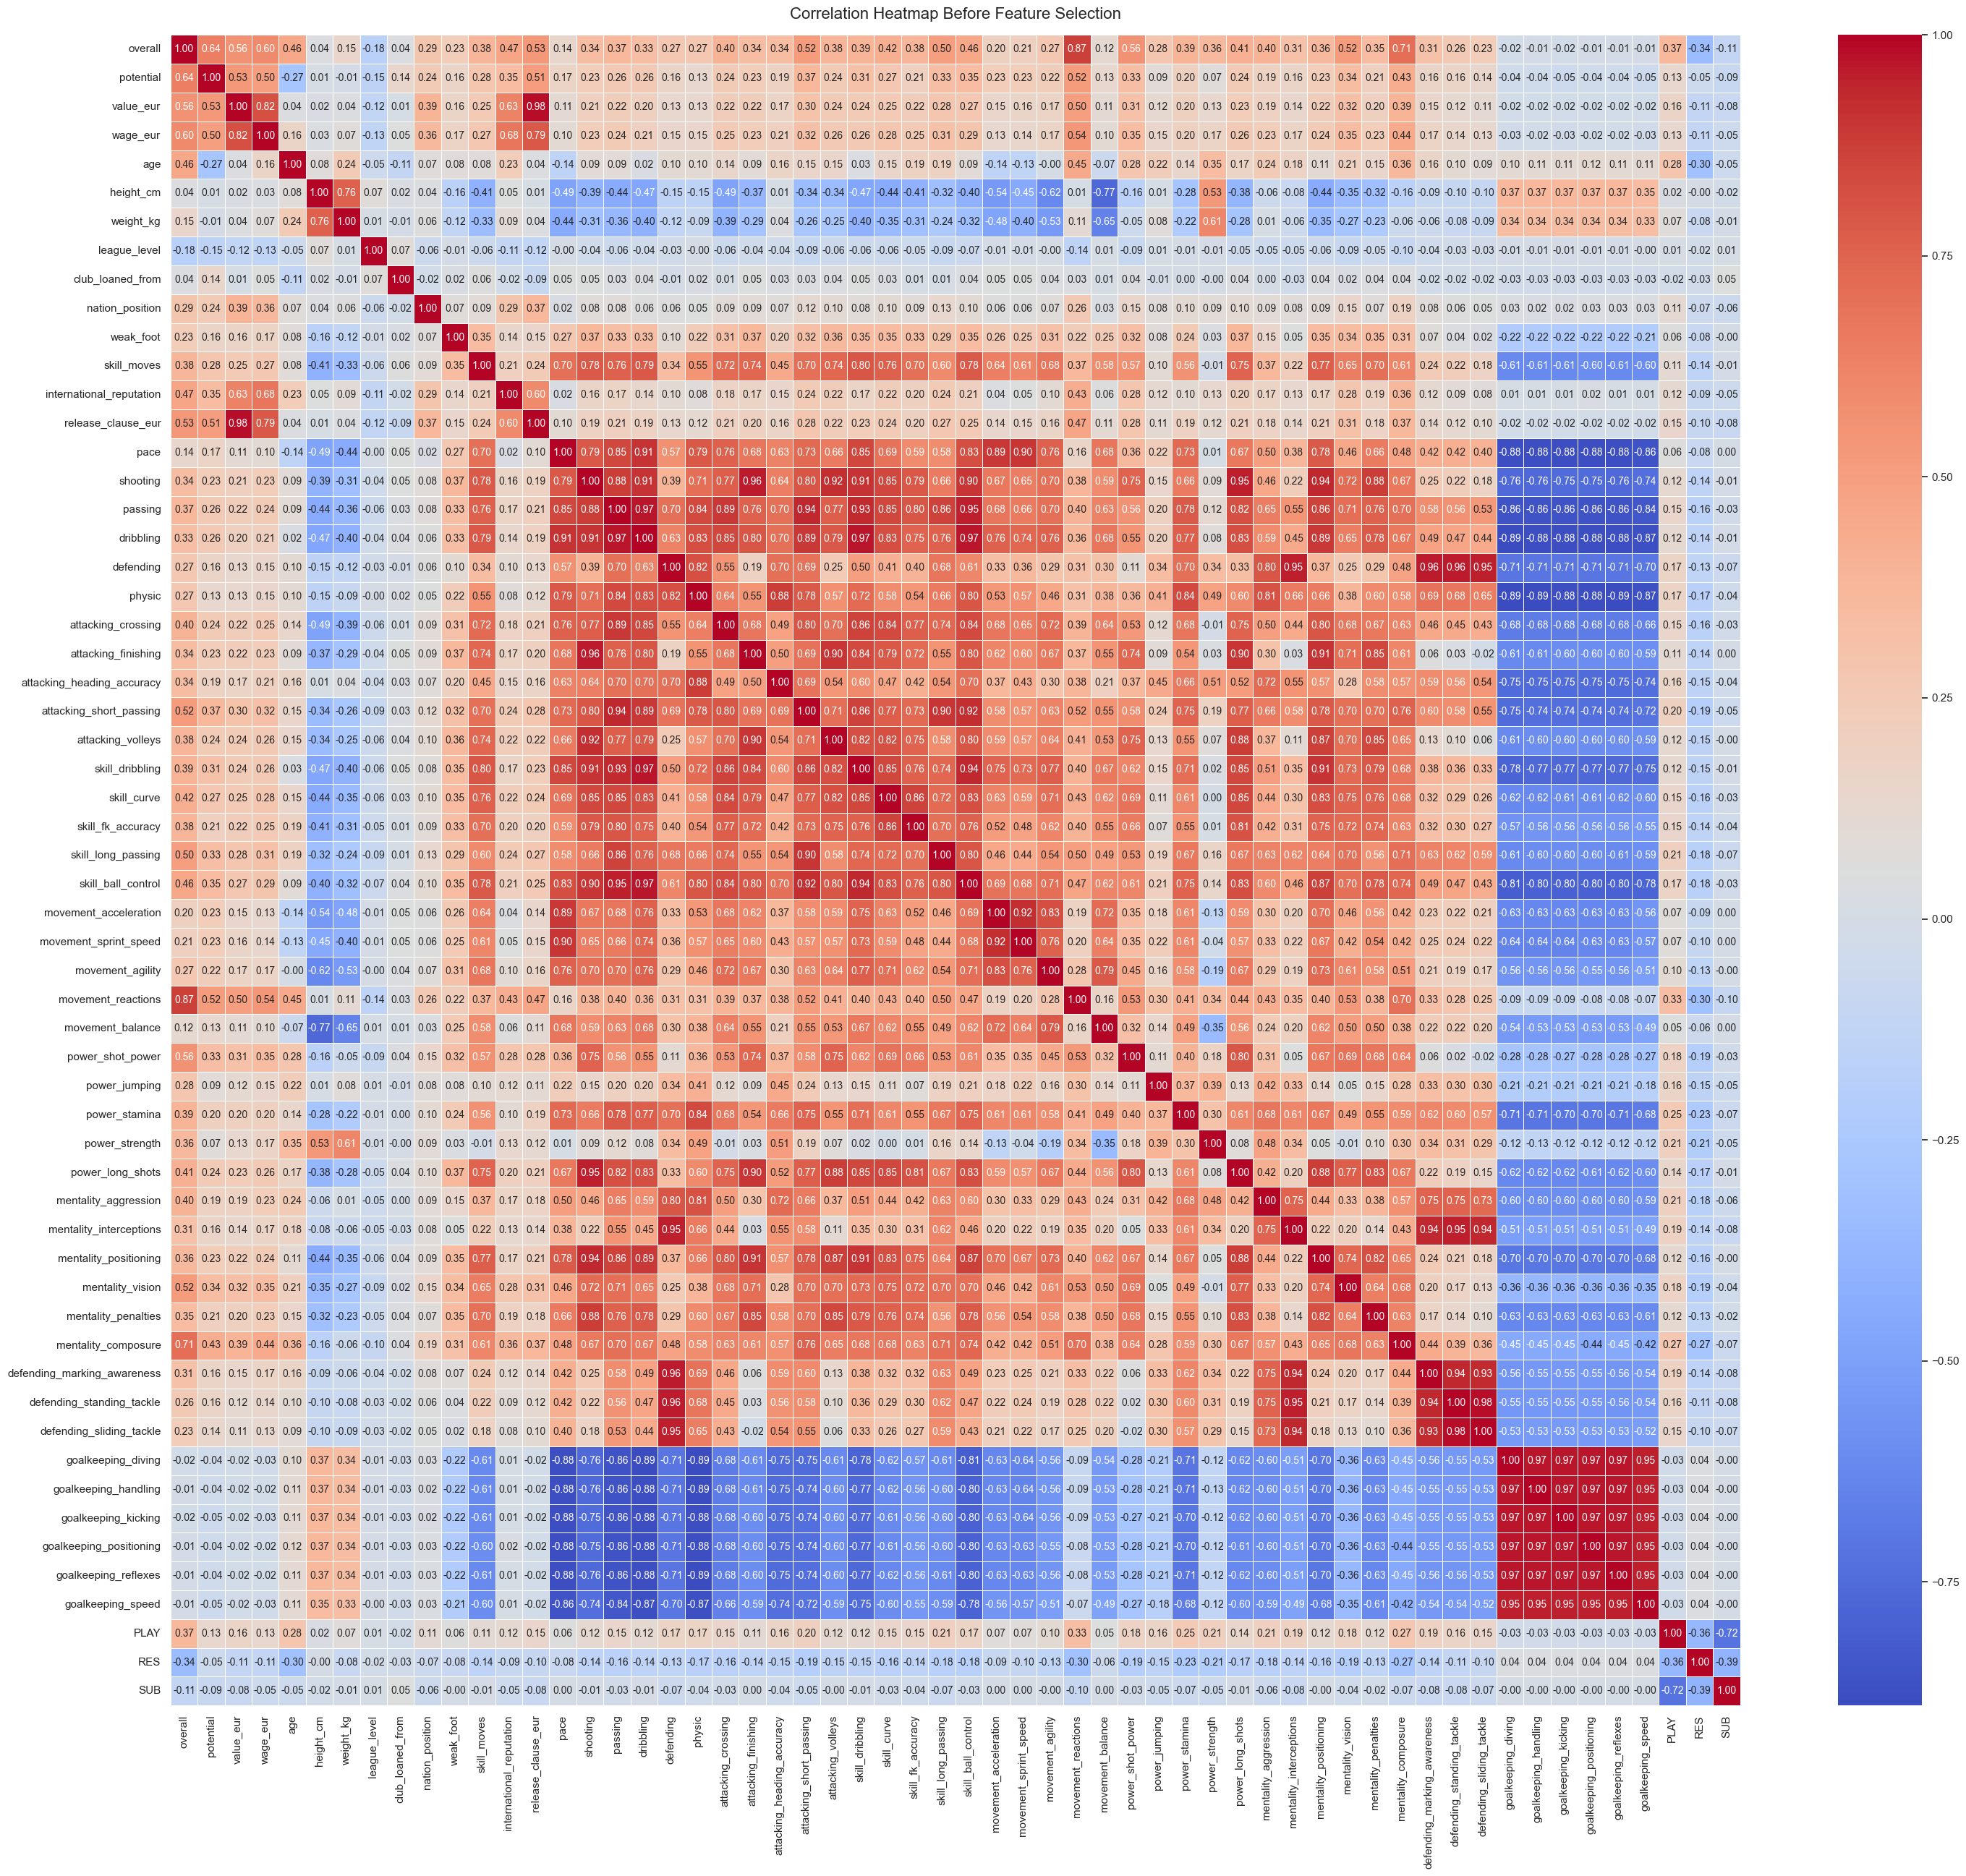

get_highly_correlated_features - List of features to drop: ['dribbling', 'attacking_finishing', 'defending_marking_awareness', 'skill_dribbling', 'goalkeeping_speed', 'movement_acceleration', 'movement_reactions', 'skill_fk_accuracy', 'defending_sliding_tackle', 'goalkeeping_reflexes', 'attacking_crossing', 'attacking_heading_accuracy', 'mentality_interceptions', 'mentality_penalties', 'movement_sprint_speed', 'skill_curve', 'goalkeeping_diving', 'defending_standing_tackle', 'goalkeeping_handling', 'passing', 'skill_ball_control', 'attacking_volleys', 'goalkeeping_positioning', 'power_long_shots', 'attacking_short_passing', 'mentality_positioning', 'skill_long_passing', 'goalkeeping_kicking']
get_target_correlated_features - Feature wage_eur is highly correlated with the target variable with a correlation of 0.8230544086115723
get_target_correlated_features - Feature release_clause_eur is highly correlated with the target variable with a correlation of 0.9758125321764652
get_target_cor

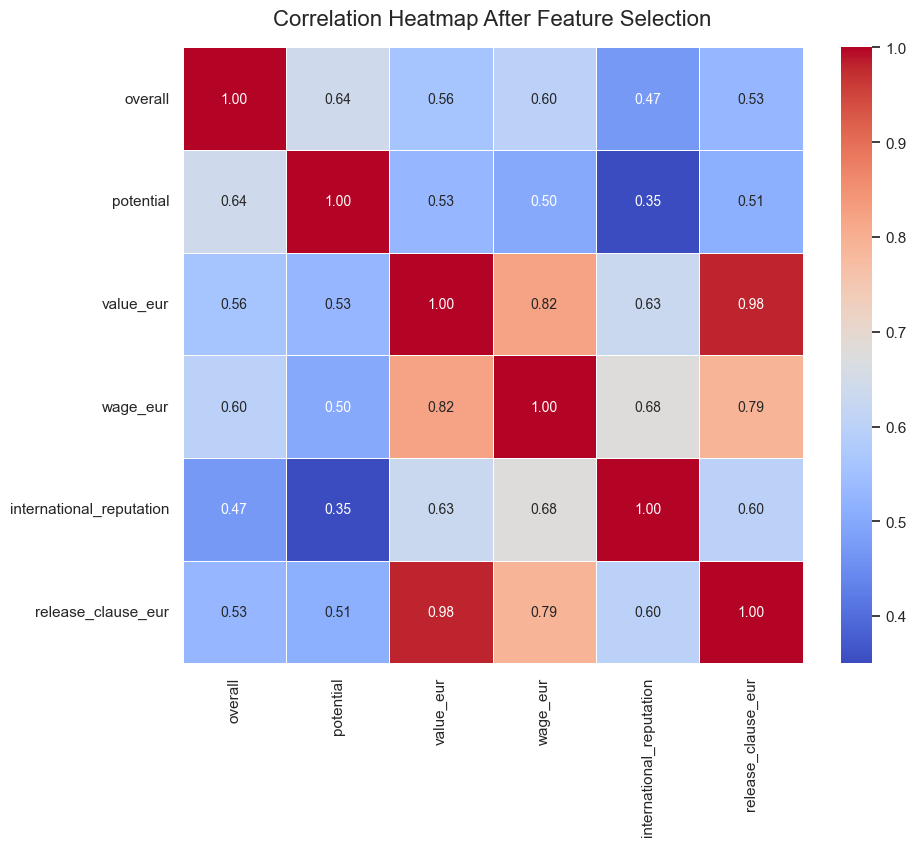

TEST DATASET - Number of features: 5
TEST DATASET - Number of samples: 3848


In [55]:
# Fixing seed for replicability
torch.manual_seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.mps.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)


verbose_train = True
verbose_test = True 


# 1. DATA LOADING
df_train = load_data(F_CSV_TRAIN, verbose_train)
df_test = load_data(F_CSV_TEST, verbose_test)    


# 2. - DATASET PRE-PROCESSING
df_train = data_pre_processing(df_train, verbose=verbose_train)
df_test = data_pre_processing(df_test, verbose=verbose_test)

# 3. FEATURES SELECTION
target = 'value_eur'
df_train = features_selection(df_train, target, verbose=verbose_train)

# 4. DATASET DEFINITION
# 4.1 For the training dataset
y = df_train[target].values                     # target variable as numpy array
X = df_train.drop(columns=[target]).values      # features  as numpy array

# Only for the training dataset
X_train, X_valid, y_train, y_valid = train_test_split(X,y, test_size=0.2, random_state=SEED, shuffle=False)

# 4.2 For the test dataset (without target variable)
lst_features = df_train.columns.tolist()
lst_features.remove(target)
X_test = df_test[lst_features].values                       
if verbose_test:
    print(f"TEST DATASET - Number of features: {len(lst_features)}")
    print(f"TEST DATASET - Number of samples: {X_test.shape[0]}")


# 5. DATA NORMALIZATION
# We use two different scalers: one for the features and one for the target variable
# to avoid the error due to the different dimensions of the dataset
scaler_X = MinMaxScaler()  # For the features
scaler_y = MinMaxScaler()  # For the target variable

# Use the scaler to normalize the data 
# Use fit_transform for features and transform for target
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))  

# "transform" (not "fit_transform") the validation set and the test set
# using the parameters calculated on the training set
# This is important for two reasons:
# 1. Avoid data leakage:
#    If we fit the scaler on the validation or test data, we would be using information from those sets to scale the training data.
#    This could lead to overfitting and an unrealistic evaluation of the model's performance.
# 2. Consistency:
#    We want to ensure that the model sees the data in the same scaled space.
#    By using the same scaler fitted on the training data, we ensure that the validation and test data are scaled in the same way.

X_valid_scaled = scaler_X.transform(X_valid)
y_valid_scaled = scaler_y.transform(y_valid.reshape(-1, 1))

X_test_scaled = scaler_X.transform(X_test)


### Models Engineering and Model Training


In this section of the code we are going to have our **Model Engineering**, meaning that we are going to compare the following models:

* **Linear Regression**: A simple linear regression

* **Ridge Regression**: A Linear Regression with L2-Regularizer

* **Lasso Regression**: A Linear Regression with L1-Regularizer

* **Elastic Net Regression**: A Linear Regression with a mix of L2 and L1 Regularizers

* **AdaBoost**: A boosting ensemble methos made on Simple Decision Trees

* **Gradient Boostin**: A different boosting ensemble method

* **Random Forest**: A bagging ensemble learning method that operates by constructing multiple decision trees during training and outputs the average prediction.

* **Simple Neural Network**: A simple neural network with just one hidden layer, fully connected and with ReLu activation



The best performing model, according to the _Root Mean Squared Error (RMSE)_ is going to be used for the prediction of the test dataset.




=== Training LINEAR REGRESSION model ===
LINEAR REGRESSION - RMSE: 1537864.0
Now the best model is LINEAR REGRESSION with RMSE: 1537864.0


=== Training RIDGE REGRESSION model ===
RIDGE REGRESSION - RMSE: 1536608.5
Now the best model is RIDGE REGRESSION with RMSE: 1536608.5


=== Training LASSO REGRESSION model ===
LASSO REGRESSION - RMSE: 7476515.8


=== Training ELASTIC NET model ===
ELASTIC NET - RMSE: 7476515.8


=== Training ADA BOOST model ===
ADA BOOST - RMSE: 769784.9
Now the best model is ADA BOOST with RMSE: 769784.9


=== Training RANDOM FOREST model ===
RANDOM FOREST - RMSE: 698883.8
Now the best model is RANDOM FOREST with RMSE: 698883.8


=== Training GRADIENT BOOSTING model ===
GRADIENT BOOSTING - RMSE: 678363.5
Now the best model is GRADIENT BOOSTING with RMSE: 678363.5


=== Training SIMPLE NEURAL NETWORK model ===


Training Progress: 100%|██████████| 1000/1000 [04:19<00:00,  3.86epoch/s]


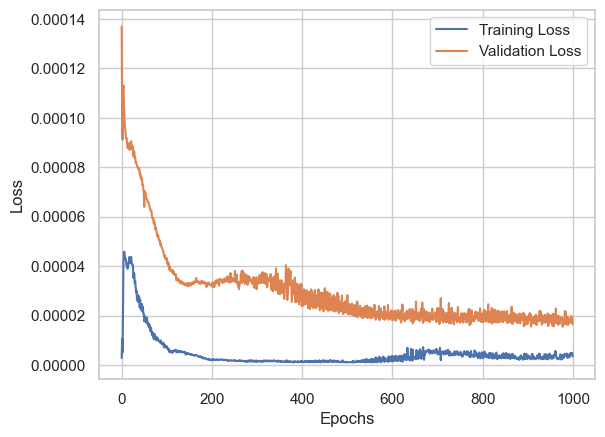

SIMPLE NEURAL NETWORK - RMSE: 558401.1
Now the best model is SIMPLE NEURAL NETWORK with RMSE: 558401.1


****************************************************************
The BEST MODEL is SIMPLE NEURAL NETWORK with RMSE: 558401.1
****************************************************************




In [56]:
 
# 6. MODEL ENGINEERING
MODELS = {
    "LINEAR REGRESSION": LinearRegression(),
    "RIDGE REGRESSION": Ridge(alpha=0.1),  # L2 regularization
    "LASSO REGRESSION": Lasso(alpha=0.1),  # L1 regularization
    "ELASTIC NET": ElasticNet(alpha=0.1, l1_ratio=0.5),  # Combination of L1 and L2
    "ADA BOOST": AdaBoostRegressor(
                    estimator=DecisionTreeRegressor(max_depth=10),  # Weak learner
                    n_estimators=100,                             # Number of weak learners
                    learning_rate=0.5,                             # Learning rate
                    random_state=SEED                              # For reproducibility
                ),
    "RANDOM FOREST": RandomForestRegressor(
                        n_estimators=350,       # Number of trees in the forest
                        min_samples_leaf= 1,    # Minimum number of samples required to be at a leaf node
                        min_samples_split=2,    # Minimum number of samples required to split an internal node
                        max_depth=100,           # Maximum depth of the trees
                        random_state=SEED,      # For reproducibility
                        n_jobs=-1               # Use all available CPU cores
                    ),  
    "GRADIENT BOOSTING": GradientBoostingRegressor(
                    n_estimators=1900,       # Number of boosting stages
                    learning_rate=0.1,      # Learning rate shrinks the contribution of each tree
                    max_depth=3,            # Maximum depth of the individual regression estimators
                    min_samples_split=4,    # Minimum number of samples required to split an internal node
                    min_samples_leaf=2,     # Minimum number of samples required to be at a leaf node
                    random_state=SEED       # For reproducibility
                ),        
    "SIMPLE NEURAL NETWORK": SimpleNeuralNetwork(
                        input_size=X_train.shape[1], # Number of features
                        hidden_size=256,             # Number of neurons in the hidden layer
                        output_size=1,               # Number of output neurons (1 for regression)   
                        batch_size=32,               # Batch size for training 
                        learning_rate=0.0001,        # Learning rate for the optimizer
                        epochs=1000)                 # Number of epochs for training       
}


best_rmse = float('inf')  # Initialize to infinity
best_model = None
best_model_name = None
best_model_rmse = None

# Main loop for training and evaluating the models
for name, model in MODELS.items():

    print(f"\n\n=== Training {name} model ===")    

    # Train the model on the training set
    if name == "SIMPLE NEURAL NETWORK":
        model.fit(X_train_scaled, y_train_scaled, X_valid_scaled, y_valid_scaled, verbose=True)
    else:
        model.fit(X_train_scaled, y_train_scaled.ravel())

    # Predict on the validation set
    y_valid_pred = model.predict(X_valid_scaled)

    # Inverse transform the predictions to the original scale
    real_valid_pred = scaler_y.inverse_transform(y_valid_pred.reshape(-1, 1))

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_valid, real_valid_pred))
    print(f"{name} - RMSE: {rmse:.1f}")
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_model_name = name
        print(f"Now the best model is {best_model_name} with RMSE: {best_rmse:.1f}")

print(f"\n\n****************************************************************")    
print(f"The BEST MODEL is {best_model_name} with RMSE: {best_rmse:.1f}")
print(f"****************************************************************\n\n")

### Cross Validation of the Best Model

After having seen which of the models was the best, to check its consistancy, we are going to run a **Cross Validation** and keep track of the error made by the model 

In [60]:
# Set up the folds for cross-validation
folds = 5
kf = KFold(n_splits=folds, shuffle=True, random_state=SEED)

print(f"Cross-validation with {folds} folds using the best model: {best_model_name}")

# Create a list to store the RMSE for each fold
rmse_list = []

X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y).float()

# Loop through each fold
for fold, (train_index, val_index) in enumerate(kf.split(X_tensor)):
    
    print(f"\nFold {fold + 1} of {folds}")

    # Reinitialize the best model
    best_model = MODELS[best_model_name]

    # Split the data into training and validation sets
    X_train_fold, X_val_fold = X_tensor[train_index], X_tensor[val_index]
    y_train_fold, y_val_fold = y_tensor[train_index], y_tensor[val_index]

    # We use two different scalers: one for the features and one for the target variable
    # to avoid the error due to the different dimensions of the dataset
    scaler_X = MinMaxScaler()  # For the features
    scaler_y = MinMaxScaler()  # For the target variable

    # Use the scaler to normalize the data 
    # Use fit_transform for features and transform for target
    X_train_scaled = scaler_X.fit_transform(X_train_fold)
    y_train_scaled = scaler_y.fit_transform(y_train_fold.reshape(-1, 1)) 

    X_valid_scaled = scaler_X.transform(X_val_fold)
    y_valid_scaled = scaler_y.transform(y_val_fold.reshape(-1, 1))

    # Train the model on the training set
    if best_model_name == "SIMPLE NEURAL NETWORK":
        best_model.fit(X_train_scaled, y_train_scaled, X_valid_scaled, y_valid_scaled, verbose=False)
    else:
        best_model.fit(X_train_scaled, y_train_scaled.ravel())


    # Predict on the validation set
    y_val_pred = best_model.predict(X_valid_scaled)

    # Inverse transform the predictions to the original scale
    real_val_pred = scaler_y.inverse_transform(y_val_pred.reshape(-1, 1))

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_val_fold, real_val_pred))
    print(f"RMSE for fold {fold + 1}: {rmse:.1f}")
    
    # Append the RMSE to the list
    rmse_list.append(rmse)


# Calculate the average RMSE across all folds
avg_rmse = np.mean(rmse_list)
print(f"\n\n****************************************************************")    
print(f"       Average RMSE across {folds} folds: {avg_rmse:.1f}")
print(f"****************************************************************\n\n")



Cross-validation with 5 folds using the best model: SIMPLE NEURAL NETWORK

Fold 1 of 5


Training Progress:  17%|█▋        | 168/1000 [00:44<03:38,  3.81epoch/s]


Early stopping at epoch 169
RMSE for fold 1: 367568.3

Fold 2 of 5


Training Progress:  15%|█▌        | 153/1000 [00:26<02:26,  5.77epoch/s]


Early stopping at epoch 154
RMSE for fold 2: 307195.0

Fold 3 of 5


...

Early stopping at epoch 151
RMSE for fold 3: 365761.6

Fold 4 of 5


Training Progress:  16%|█▌        | 159/1000 [00:25<02:15,  6.20epoch/s]


Early stopping at epoch 160
RMSE for fold 4: 304464.0

Fold 5 of 5


Training Progress:  16%|█▌        | 157/1000 [00:25<02:17,  6.15epoch/s]

Early stopping at epoch 158
RMSE for fold 5: 346341.2


****************************************************************
       Average RMSE across 5 folds: 338266.0
****************************************************************




## Test Prediction

Now that we have found the best model, we can retrain the model on the whole training set and use it to predict the **Market Value** of players in the test set.

Finally we are going to save the prediction in a CSV File

In [61]:
# Retrain the best model on the entire training set
print(f"\n\n=== Retraining the best model {best_model_name} on the entire training set ===")

# Reinitialize the best model
best_model = MODELS[best_model_name]

# We use two different scalers: one for the features and one for the target variable
# to avoid the error due to the different dimensions of the dataset
scaler_X = MinMaxScaler()  # For the features
scaler_y = MinMaxScaler()  # For the target variable

# Use the scaler to normalize the data
# Use fit_transform for features and transform for target
X_train_scaled = scaler_X.fit_transform(X)
y_train_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Train the model on the entire training set
if best_model_name == "SIMPLE NEURAL NETWORK":
    best_model.fit(X_train_scaled, y_train_scaled, X_train_scaled, y_train_scaled, verbose=False)
else:
    best_model.fit(X_train_scaled, y_train_scaled.ravel())


# Predict on the TEST set
y_test_pred = best_model.predict(X_test_scaled)

# Inverse transform the predictions to the original scale
real_test_pred = scaler_y.inverse_transform(y_test_pred.reshape(-1, 1))

print(f"\nTEST DATASET - Prediction {real_test_pred}")

# Save the predictions to a CSV file
df_predictions = pd.DataFrame(real_test_pred, columns=["value_eur"])
df_predictions.to_csv(F_CSV_SUB, index=False)
print(f"\nSUBMISSION FILE {F_CSV_SUB} saved!\n\n")



=== Retraining the best model SIMPLE NEURAL NETWORK on the entire training set ===


Training Progress:  19%|█▉        | 191/1000 [00:47<03:22,  3.99epoch/s]

Early stopping at epoch 192

TEST DATASET - Prediction [[1002417.75]
 [ 298982.7 ]
 [ 147443.7 ]
 ...
 [ 579674.56]
 [ 928056.6 ]
 [1302204.9 ]]

SUBMISSION FILE ./data/submission.csv saved!


